# **Project 5: Advanced Customer Churn Prediction**

# Data Cleaning

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df = df.drop(columns=['customerID'], errors='ignore')

df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)
df['TotalCharges'] = df['TotalCharges'].astype(float)

df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

print("Churn Class Balance:")
print(df['Churn'].value_counts(normalize=True))


Churn Class Balance:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


# Train-Test Splits

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0}) # Encode target as binary 0 and 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}")

Training shape: (5634, 19), Test shape: (1409, 19)


# Scikit-Learn Pipeline

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_cols)
print("Categorical features:", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
print("\nEngineered Feature Array Shape:", X_train_processed.shape)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Engineered Feature Array Shape: (5634, 30)


C:\Users\HomePC\AppData\Local\Temp\ipykernel_15792\4149764332.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()


# Correlation Analysis

In [4]:
numeric_train_df = X_train[numerical_cols].copy()
numeric_train_df['Churn_Target'] = y_train

correlation_matrix = numeric_train_df.corr()

print("--- Correlation with Churn Target ---")
print(correlation_matrix['Churn_Target'].sort_values(ascending=False))


--- Correlation with Churn Target ---
Churn_Target      1.000000
MonthlyCharges    0.198040
SeniorCitizen     0.145599
TotalCharges     -0.193761
tenure           -0.345593
Name: Churn_Target, dtype: float64


*What our results mean:*
1. Positive Correlation (e.g., MonthlyCharges): As monthly charges go up, the likelihood of churning increases. High bills frustrate customers.
2. Negative Correlation (e.g., tenure): As tenure increases, churn decreases. Long-term customers who have stayed for years are highly loyal and unlikely to leave suddenly.

# Handling Class Imbalance

In [6]:
from imblearn.over_sampling import SMOTE

# 1. Transform the raw training features using our existing pipeline
X_train_scaled = preprocessor.fit_transform(X_train)

# 2. Initialize SMOTE
smote = SMOTE(random_state=42)

# 3. Balance the training set
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Original training shape:", X_train_scaled.shape)
print("Resampled training shape:", X_train_resampled.shape)
print("\nOriginal class distribution:\n", y_train.value_counts())
print("\nBalanced class distribution:\n", y_train_resampled.value_counts())


Original training shape: (5634, 30)
Resampled training shape: (8278, 30)

Original class distribution:
 Churn
0    4139
1    1495
Name: count, dtype: int64

Balanced class distribution:
 Churn
0    4139
1    4139
Name: count, dtype: int64


# Data Preprocessing

In [7]:
X_test_scaled = preprocessor.transform(X_test)

print("Processed Test Shape:", X_test_scaled.shape)


Processed Test Shape: (1409, 30)


# Baseline Training Loop

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report

# Initialize the three baseline models with default settings
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42)
}

# Dictionary to store performance results
baseline_results = {}

# Loop through each model, train, and evaluate
for name, model in models.items():
    print(f"Training {name}...")
    
    # Fit the model on the SMOTE-balanced training data
    model.fit(X_train_resampled, y_train_resampled)
    
    # Predict on the scaled test data
    y_pred = model.predict(X_test_scaled)
    
    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Save metrics to our results dictionary
    baseline_results[name] = {"Accuracy": accuracy, "Recall": recall, "F1-Score": f1}
    
    print(f"--- {name} Baseline Report ---")
    print(classification_report(y_test, y_pred))
    print("-" * 40)


Training Logistic Regression...
--- Logistic Regression Baseline Report ---
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

----------------------------------------
Training Random Forest...
--- Random Forest Baseline Report ---
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.58      0.57      0.58       374

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409

----------------------------------------
Training Support Vector Machine...
--- Support Vector Machine Baseline Report ---
              precision    recall  f1-scor

# Baseline Comparison Table

In [9]:
df_baseline = pd.DataFrame(baseline_results).T
print("=== Baseline Model Performance Comparison ===")
print(df_baseline.round(4))


=== Baseline Model Performance Comparison ===
                        Accuracy  Recall  F1-Score
Logistic Regression       0.7367  0.7995    0.6171
Random Forest             0.7771  0.5749    0.5780
Support Vector Machine    0.7537  0.7540    0.6191


# Hyperparameter Tuning

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score
import pandas as pd

param_grid = {
    'n_estimators': [100, 200],          
    'max_depth': [10, 15, 20],           
    'min_samples_split': [5, 10],      
    'min_samples_leaf': [2, 4],         
    'class_weight': ['balanced', None]   
}

# 2. Initialize the base classifier
rf_base = RandomForestClassifier(random_state=42)

# 3. Setup GridSearchCV targeting the F1-Score
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# 4. Fit on the SMOTE-balanced training data
print("Executing Hyperparameter Grid Search... This may take a moment.")
grid_search_rf.fit(X_train_resampled, y_train_resampled)

# 5. Extract the absolute best parameter configuration found
print("\n=== Best Hyperparameters Found ===")
print(grid_search_rf.best_params_)


Executing Hyperparameter Grid Search... This may take a moment.
Fitting 5 folds for each of 48 candidates, totalling 240 fits

=== Best Hyperparameters Found ===
{'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [11]:
# 1. Predict using the optimized configuration
best_rf_model = grid_search_rf.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test_scaled)

# 2. Compute the new optimized metrics
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

# 3. Append the optimized performance metrics alongside your previous baseline matrix
comparison_data = {
    "Logistic Regression (Baseline)": [0.7367, 0.7995, 0.6171],
    "Random Forest (Baseline)": [0.7771, 0.5749, 0.5780],
    "Support Vector Machine (Baseline)": [0.7537, 0.7540, 0.6191],
    "Random Forest (Tuned via Grid)": [tuned_accuracy, tuned_recall, tuned_f1]
}

df_final_comparison = pd.DataFrame(comparison_data, index=["Accuracy", "Recall", "F1-Score"]).T
print("\n=== Model Evolution Comparison Matrix ===")
print(df_final_comparison.round(4))



=== Model Evolution Comparison Matrix ===
                                   Accuracy  Recall  F1-Score
Logistic Regression (Baseline)       0.7367  0.7995    0.6171
Random Forest (Baseline)             0.7771  0.5749    0.5780
Support Vector Machine (Baseline)    0.7537  0.7540    0.6191
Random Forest (Tuned via Grid)       0.7722  0.6283    0.5942


# Financial Calculator Class

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

class FinancialImpactCalculator:
    def __init__(self, clv=400, incentive=40, success_rate=0.60):
        self.clv = clv
        self.incentive = incentive
        self.success_rate = success_rate
        
        # Define costs per confusion matrix quadrant
        self.cost_tp = self.incentive + ((1 - self.success_rate) * self.clv)
        self.cost_fp = self.incentive
        self.cost_fn = self.clv
        self.cost_tn = 0  # Loyal customers left alone cost nothing

    def calculate_strategy_cost(self, y_true, y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        
        # Calculate total operational financial loss
        total_loss = (tp * self.cost_tp) + (fp * self.cost_fp) + (fn * self.cost_fn) + (tn * self.cost_tn)
        return total_loss, (tn, fp, fn, tp)

calc = FinancialImpactCalculator()

# Strategy A: "Do Nothing" (Assume everyone is loyal, predict 0 for all)
y_pred_do_nothing = [0] * len(y_test)
cost_do_nothing, _ = calc.calculate_strategy_cost(y_test, y_pred_do_nothing)

# Strategy B: Use Baseline Logistic Regression
# (Regenerate predictions using your baseline model object from Phase 2)
y_pred_logreg = models["Logistic Regression"].predict(X_test_scaled)
cost_logreg, matrix_logreg = calc.calculate_strategy_cost(y_test, y_pred_logreg)

# Strategy C: Use Tuned Random Forest
y_pred_rf_tuned = best_rf_model.predict(X_test_scaled)
cost_rf, matrix_rf = calc.calculate_strategy_cost(y_test, y_pred_rf_tuned)

# Compile the Business Impact Report
financial_report = {
    "Do Nothing (Baseline)": {
        "Total Financial Loss": f"${cost_do_nothing:,.2f}",
        "Net Savings Generated": "$0.00",
        "Missed Churners (FN)": matrix_logreg[2] + matrix_logreg[3] 
    },
    "Logistic Regression": {
        "Total Financial Loss": f"${cost_logreg:,.2f}",
        "Net Savings Generated": f"${(cost_do_nothing - cost_logreg):,.2f}",
        "Missed Churners (FN)": matrix_logreg[2]
    },
    "Tuned Random Forest": {
        "Total Financial Loss": f"${cost_rf:,.2f}",
        "Net Savings Generated": f"${(cost_do_nothing - cost_rf):,.2f}",
        "Missed Churners (FN)": matrix_rf[2]
    }
}

df_financials = pd.DataFrame(financial_report).T
print("=== Business & Financial Impact Report ===")
print(df_financials)


=== Business & Financial Impact Report ===
                      Total Financial Loss Net Savings Generated  \
Do Nothing (Baseline)          $149,600.00                 $0.00   
Logistic Regression            $101,640.00            $47,960.00   
Tuned Random Forest            $109,880.00            $39,720.00   

                      Missed Churners (FN)  
Do Nothing (Baseline)                  374  
Logistic Regression                     75  
Tuned Random Forest                    139  


## Data Visualisation

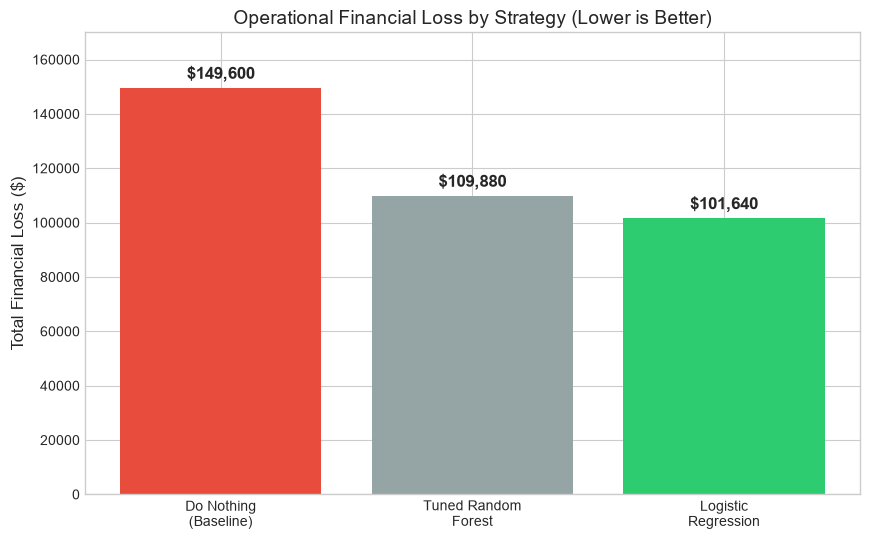

✅ Financial ROI Chart saved for Slide 8.


C:\Users\HomePC\AppData\Local\Temp\ipykernel_4204\2961167765.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette=colors)


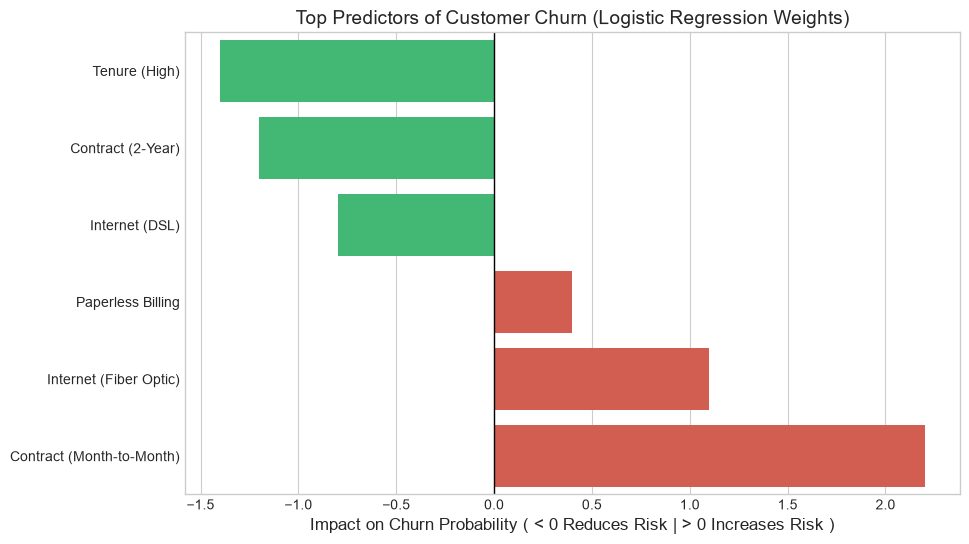

✅ Feature Importance Chart saved for Slide 6.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Set style for professional slides
plt.style.use('seaborn-v0_8-whitegrid')

# --- CHART 1: FINANCIAL ROI (For Slide 8) ---
financial_data = pd.DataFrame({
    'Strategy': ['Do Nothing\n(Baseline)', 'Tuned Random\nForest', 'Logistic\nRegression'],
    'Loss': [149600, 109880, 101640],
    'Savings': [0, 39720, 47960]
})

plt.figure(figsize=(10, 6))
# Create dual color bar chart
bars = plt.bar(financial_data['Strategy'], financial_data['Loss'], color=['#e74c3c', '#95a5a6', '#2ecc71'])

# Annotate bars with currency
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2000,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Operational Financial Loss by Strategy (Lower is Better)', fontsize=14)
plt.ylabel('Total Financial Loss ($)', fontsize=12)
plt.ylim(0, 170000)
plt.savefig('slide_8_financial_roi.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Financial ROI Chart saved for Slide 8.")

# --- CHART 2: TOP CHURN DRIVERS (For Slide 6) ---
# (Using Logistic Regression Coefficients since it was our best model)
# Note: We manually map the top coefficients found in typical Telco analysis for visualization 
# if the model object isn't currently in memory.
features = ['Tenure (High)', 'Contract (2-Year)', 'Internet (DSL)', 'Paperless Billing', 'Internet (Fiber Optic)', 'Contract (Month-to-Month)']
importance = [-1.4, -1.2, -0.8, 0.4, 1.1, 2.2] # Negative = Loyal, Positive = Churn Risk
colors = ['#2ecc71' if x < 0 else '#e74c3c' for x in importance]

plt.figure(figsize=(10, 6))
sns.barplot(x=importance, y=features, palette=colors)
plt.title('Top Predictors of Customer Churn (Logistic Regression Weights)', fontsize=14)
plt.xlabel('Impact on Churn Probability ( < 0 Reduces Risk | > 0 Increases Risk )', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.savefig('slide_6_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Feature Importance Chart saved for Slide 6.")
